# 风格迁移

摄影爱好者也许接触过滤波器。它能改变照片的颜色风格，从而使风景照更加锐利或者令人像更加美白。但一个滤波器通常只能改变照片的某个方面。如果要照片达到理想中的风格，可能需要尝试大量不同的组合。这个过程的复杂程度不亚于模型调参。

本节将介绍如何使用卷积神经网络，自动将一个图像中的风格应用在另一图像之上，即*风格迁移*（style transfer） :cite:`Gatys.Ecker.Bethge.2016`。
这里我们需要两张输入图像：一张是*内容图像*，另一张是*风格图像*。
我们将使用神经网络修改内容图像，使其在风格上接近风格图像。
例如， :numref:`fig_style_transfer`中的内容图像为本书作者在西雅图郊区的雷尼尔山国家公园拍摄的风景照，而风格图像则是一幅主题为秋天橡树的油画。
最终输出的合成图像应用了风格图像的油画笔触让整体颜色更加鲜艳，同时保留了内容图像中物体主体的形状。

![输入内容图像和风格图像，输出风格迁移后的合成图像](../img/style-transfer.svg)
:label:`fig_style_transfer`

## 方法

 :numref:`fig_style_transfer_model`用简单的例子阐述了基于卷积神经网络的风格迁移方法。
首先，我们初始化合成图像，例如将其初始化为内容图像。
该合成图像是风格迁移过程中唯一需要更新的变量，即风格迁移所需迭代的模型参数。
然后，我们选择一个预训练的卷积神经网络来抽取图像的特征，其中的模型参数在训练中无须更新。
这个深度卷积神经网络凭借多个层逐级抽取图像的特征，我们可以选择其中某些层的输出作为内容特征或风格特征。
以 :numref:`fig_style_transfer_model`为例，这里选取的预训练的神经网络含有3个卷积层，其中第二层输出内容特征，第一层和第三层输出风格特征。

![基于卷积神经网络的风格迁移。实线箭头和虚线箭头分别表示前向传播和反向传播](../img/neural-style.svg)
:label:`fig_style_transfer_model`

接下来，我们通过前向传播（实线箭头方向）计算风格迁移的损失函数，并通过反向传播（虚线箭头方向）迭代模型参数，即不断更新合成图像。
风格迁移常用的损失函数由3部分组成：

1. *内容损失*使合成图像与内容图像在内容特征上接近；
1. *风格损失*使合成图像与风格图像在风格特征上接近；
1. *全变分损失*则有助于减少合成图像中的噪点。

最后，当模型训练结束时，我们输出风格迁移的模型参数，即得到最终的合成图像。

在下面，我们将通过代码来进一步了解风格迁移的技术细节。

## [**阅读内容和风格图像**]

首先，我们读取内容和风格图像。
从打印出的图像坐标轴可以看出，它们的尺寸并不一样。


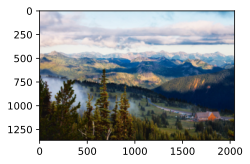

In [1]:
# 导入必要的库
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

# 设置图像显示的默认尺寸
d2l.set_figsize()
# 读取内容图像（雷尼尔山风景照）
content_img = d2l.Image.open('../img/rainier.jpg')
d2l.plt.imshow(content_img);

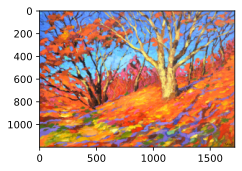

In [2]:
# 读取风格图像（秋天橡树油画）
style_img = d2l.Image.open('../img/autumn-oak.jpg')
d2l.plt.imshow(style_img);

## [**预处理和后处理**]

下面，定义图像的预处理函数和后处理函数。
预处理函数`preprocess`对输入图像在RGB三个通道分别做标准化，并将结果变换成卷积神经网络接受的输入格式。
后处理函数`postprocess`则将输出图像中的像素值还原回标准化之前的值。
由于图像打印函数要求每个像素的浮点数值在0～1之间，我们对小于0和大于1的值分别取0和1。


In [3]:
# ImageNet 数据集的 RGB 三通道均值和标准差（用于标准化）
rgb_mean = torch.tensor([0.485, 0.456, 0.406])
rgb_std = torch.tensor([0.229, 0.224, 0.225])

def preprocess(img, image_shape):
    """预处理函数：将输入图像转换为 CNN 可接受的格式
    
    参数:
        img: PIL 图像
        image_shape: (height, width) 目标尺寸
        
    返回:
        形状 [1, 3, H, W] 的张量，已标准化
        1 是批量维度，3 是 RGB 通道，H, W 是调整后的高宽
    """
    transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize(image_shape),  # 调整图像尺寸为 (H, W)
        torchvision.transforms.ToTensor(),           # 转换为 [3, H, W] 张量，像素值缩放到 [0, 1]
        torchvision.transforms.Normalize(mean=rgb_mean, std=rgb_std)  # 按通道标准化
    ])
    # transforms(img): [3, H, W]
    # unsqueeze(0): [1, 3, H, W]，添加批量维度
    return transforms(img).unsqueeze(0)

def postprocess(img):
    """后处理函数：将标准化后的张量还原为可显示的图像
    
    参数:
        img: 形状 [1, 3, H, W] 的标准化张量
        
    返回:
        PIL 图像，像素值在 [0, 1] 之间
    """
    # img[0]: 去除批量维度，[3, H, W]
    # to(rgb_std.device): 确保张量在与 std 相同的设备上
    img = img[0].to(rgb_std.device)
    # permute(1, 2, 0): [3, H, W] -> [H, W, 3]，将通道维移到最后
    # * rgb_std + rgb_mean: 反标准化，还原到原始像素范围
    # clamp(0, 1): 将像素值限制在 [0, 1] 范围内，防止溢出
    img = torch.clamp(img.permute(1, 2, 0) * rgb_std + rgb_mean, 0, 1)
    # permute(2, 0, 1): [H, W, 3] -> [3, H, W]，转回通道在前的格式供 ToPILImage 使用
    return torchvision.transforms.ToPILImage()(img.permute(2, 0, 1))

## [**抽取图像特征**]

我们使用基于ImageNet数据集预训练的VGG-19模型来抽取图像特征 :cite:`Gatys.Ecker.Bethge.2016`。


In [ ]:
# 加载基于 ImageNet 数据集预训练的 VGG-19 模型
# pretrained=True 表示使用预训练权重（用于抽取图像特征）
pretrained_net = torchvision.models.vgg19(pretrained=True)

为了抽取图像的内容特征和风格特征，我们可以选择VGG网络中某些层的输出。
一般来说，越靠近输入层，越容易抽取图像的细节信息；反之，则越容易抽取图像的全局信息。
为了避免合成图像过多保留内容图像的细节，我们选择VGG较靠近输出的层，即*内容层*，来输出图像的内容特征。
我们还从VGG中选择不同层的输出来匹配局部和全局的风格，这些图层也称为*风格层*。
正如 :numref:`sec_vgg`中所介绍的，VGG网络使用了5个卷积块。
实验中，我们选择第四卷积块的最后一个卷积层作为内容层，选择每个卷积块的第一个卷积层作为风格层。
这些层的索引可以通过打印`pretrained_net`实例获取。


In [ ]:
# 定义风格层和内容层在 VGG-19 features 中的索引
# VGG-19 的卷积块结构：
#   卷积块 1: 层 0-4 (0,1,2 是卷积层，3 是 ReLU，4 是池化)
#   卷积块 2: 层 5-9
#   卷积块 3: 层 10-18
#   卷积块 4: 层 19-27
#   卷积块 5: 层 28-36
# 选择每个卷积块的第一个卷积层作为风格层：[0, 5, 10, 19, 28]
# 选择第四卷积块的最后一个卷积层（层 25）作为内容层
style_layers, content_layers = [0, 5, 10, 19, 28], [25]

使用VGG层抽取特征时，我们只需要用到从输入层到最靠近输出层的内容层或风格层之间的所有层。
下面构建一个新的网络`net`，它只保留需要用到的VGG的所有层。


In [ ]:
# 构建一个新的网络，只保留需要用到的 VGG 层
# max(content_layers + style_layers) + 1 = max([25, 0, 5, 10, 19, 28]) + 1 = 29
# 所以我们保留 pretrained_net.features 的前 29 层（索引 0-28）
# 这样可以从输入层到最深层的内容层/风格层，抽取所有需要的特征
net = nn.Sequential(*[pretrained_net.features[i] for i in
                      range(max(content_layers + style_layers) + 1)])

给定输入`X`，如果我们简单地调用前向传播`net(X)`，只能获得最后一层的输出。
由于我们还需要中间层的输出，因此这里我们逐层计算，并保留内容层和风格层的输出。


In [ ]:
def extract_features(X, content_layers, style_layers):
    """抽取图像的内容特征和风格特征
    
    参数:
        X: 输入图像张量，形状 [1, 3, H, W]
        content_layers: 内容层索引列表
        style_layers: 风格层索引列表
        
    返回:
        contents: 内容特征列表，每个元素是对应内容层的输出张量
        styles: 风格特征列表，每个元素是对应风格层的输出张量
    """
    contents = []
    styles = []
    # 逐层前向传播，保留中间层的输出
    for i in range(len(net)):
        # 通过第 i 层，X 的形状会随着网络深度而变化
        # 卷积层会改变通道数，池化层会改变高宽
        X = net[i](X)
        # 如果当前层是风格层，保存该层的输出
        if i in style_layers:
            styles.append(X)  # X 形状：[1, C, H, W]，C 和 H, W 随层深变化
        # 如果当前层是内容层，保存该层的输出
        if i in content_layers:
            contents.append(X)  # X 形状：[1, C, H, W]
    return contents, styles

下面定义两个函数：`get_contents`函数对内容图像抽取内容特征；
`get_styles`函数对风格图像抽取风格特征。
因为在训练时无须改变预训练的VGG的模型参数，所以我们可以在训练开始之前就提取出内容特征和风格特征。
由于合成图像是风格迁移所需迭代的模型参数，我们只能在训练过程中通过调用`extract_features`函数来抽取合成图像的内容特征和风格特征。


In [ ]:
def get_contents(image_shape, device):
    """对内容图像抽取内容特征
    
    参数:
        image_shape: (height, width) 图像尺寸
        device: 计算设备（CPU 或 GPU）
        
    返回:
        content_X: 预处理后的内容图像，形状 [1, 3, H, W]
        contents_Y: 内容特征列表
    """
    # preprocess 返回 [1, 3, H, W] 张量
    content_X = preprocess(content_img, image_shape).to(device)
    # 提取内容特征，contents_Y 是列表，每个元素形状 [1, C, H, W]
    contents_Y, _ = extract_features(content_X, content_layers, style_layers)
    return content_X, contents_Y

def get_styles(image_shape, device):
    """对风格图像抽取风格特征
    
    参数:
        image_shape: (height, width) 图像尺寸
        device: 计算设备（CPU 或 GPU）
        
    返回:
        style_X: 预处理后的风格图像，形状 [1, 3, H, W]
        styles_Y: 风格特征列表
    """
    style_X = preprocess(style_img, image_shape).to(device)
    # 提取风格特征，styles_Y 是列表，每个元素形状 [1, C, H, W]
    _, styles_Y = extract_features(style_X, content_layers, style_layers)
    return style_X, styles_Y

## [**定义损失函数**]

下面我们来描述风格迁移的损失函数。
它由内容损失、风格损失和全变分损失3部分组成。

### 内容损失

与线性回归中的损失函数类似，内容损失通过平方误差函数衡量合成图像与内容图像在内容特征上的差异。
平方误差函数的两个输入均为`extract_features`函数计算所得到的内容层的输出。


In [ ]:
def content_loss(Y_hat, Y):
    """内容损失函数：衡量合成图像与内容图像在内容特征上的差异
    
    参数:
        Y_hat: 合成图像在内容层的输出，形状 [1, C, H, W]
        Y: 内容图像在内容层的输出，形状 [1, C, H, W]
        
    返回:
        标量损失值，使用平方误差均值
    """
    # Y.detach(): 从计算图中分离，不更新内容图像的特征（只更新合成图像）
    # Y_hat - Y.detach(): 逐元素差异，形状 [1, C, H, W]
    # square(): 逐元素平方
    # mean(): 求所有元素的均值，返回标量
    return torch.square(Y_hat - Y.detach()).mean()

### 风格损失

风格损失与内容损失类似，也通过平方误差函数衡量合成图像与风格图像在风格上的差异。
为了表达风格层输出的风格，我们先通过`extract_features`函数计算风格层的输出。
假设该输出的样本数为1，通道数为$c$，高和宽分别为$h$和$w$，我们可以将此输出转换为矩阵$\mathbf{X}$，其有$c$行和$hw$列。
这个矩阵可以被看作由$c$个长度为$hw$的向量$\mathbf{x}_1, \ldots, \mathbf{x}_c$组合而成的。其中向量$\mathbf{x}_i$代表了通道$i$上的风格特征。

在这些向量的*格拉姆矩阵*$\mathbf{X}\mathbf{X}^\top \in \mathbb{R}^{c \times c}$中，$i$行$j$列的元素$x_{ij}$即向量$\mathbf{x}_i$和$\mathbf{x}_j$的内积。它表达了通道$i$和通道$j$上风格特征的相关性。我们用这样的格拉姆矩阵来表达风格层输出的风格。
需要注意的是，当$hw$的值较大时，格拉姆矩阵中的元素容易出现较大的值。
此外，格拉姆矩阵的高和宽皆为通道数$c$。
为了让风格损失不受这些值的大小影响，下面定义的`gram`函数将格拉姆矩阵除以了矩阵中元素的个数，即$chw$。


In [ ]:
def gram(X):
    """计算格拉姆矩阵（Gram Matrix），用于表达风格特征
    
    格拉姆矩阵捕捉通道间的相关性，用于风格迁移中的风格表示
    
    参数:
        X: 风格层输出张量，形状 [1, C, H, W]
        其中：1=批量大小，C=通道数，H=高，W=宽
        
    返回:
        格拉姆矩阵，形状 [C, C]
        矩阵元素 (i,j) 表示通道 i 和通道 j 的特征相关性
    """
    # 提取通道数 C
    num_channels = X.shape[1]  # C
    # 计算每个通道的特征数量（高×宽）
    n = X.numel() // X.shape[1]  # numel() = 1*C*H*W, 所以 n = H*W
    
    # 重塑张量：从 [1, C, H, W] 变为 [C, H*W]
    # 第一维是通道索引，第二维是该通道所有位置的特征展平
    # reshape 后：X[i] 表示第 i 个通道的所有位置特征（长度为 H*W 的向量）
    X = X.reshape((num_channels, n))
    
    # 计算格拉姆矩阵：X @ X.T
    # X: [C, H*W], X.T: [H*W, C]
    # X @ X.T: [C, C]
    # (X @ X.T)[i,j] = X[i] · X[j] = 通道 i 和通道 j 特征向量的内积
    # 内积越大，表示两个通道的特征越相关
    # 除以 (num_channels * n) 进行归一化，避免数值过大
    return torch.matmul(X, X.T) / (num_channels * n)

1. **通道** = 特征基元（纹理元素、颜色、边缘等），不是完整的风格。
2. **空间维度** = 特征出现的位置。
3. **Gram 矩阵** = 对每个通道对，计算它们在所有空间位置上的内积，得到通道间的**成对相关性**。
4. 这个操作消除了空间信息，保留了**特征共现的统计结构**。
5. 这种统计结构正是纹理/风格的数学表达，因此 Gram 矩阵可以作为风格表征。

自然地，风格损失的平方误差函数的两个格拉姆矩阵输入分别基于合成图像与风格图像的风格层输出。这里假设基于风格图像的格拉姆矩阵`gram_Y`已经预先计算好了。


In [ ]:
def style_loss(Y_hat, gram_Y):
    """风格损失函数：衡量合成图像与风格图像在风格特征上的差异
    
    参数:
        Y_hat: 合成图像在风格层的输出，形状 [1, C, H, W]
        gram_Y: 风格图像的格拉姆矩阵（已预先计算好），形状 [C, C]
        
    返回:
        标量损失值，使用格拉姆矩阵的平方误差均值
    """
    # gram(Y_hat): 计算合成图像风格层输出的格拉姆矩阵，形状 [C, C]
    # gram_Y.detach(): 从计算图中分离，不更新风格图像的特征
    # 两者相减后平方，再求均值
    return torch.square(gram(Y_hat) - gram_Y.detach()).mean()

### 全变分损失

有时候，我们学到的合成图像里面有大量高频噪点，即有特别亮或者特别暗的颗粒像素。
一种常见的去噪方法是*全变分去噪*（total variation denoising）：
假设$x_{i, j}$表示坐标$(i, j)$处的像素值，降低全变分损失

$$\sum_{i, j} \left|x_{i, j} - x_{i+1, j}\right| + \left|x_{i, j} - x_{i, j+1}\right|$$

能够尽可能使邻近的像素值相似。


In [ ]:
def tv_loss(Y_hat):
    """全变分损失（Total Variation Loss）：减少合成图像中的高频噪点
    
    全变分去噪通过降低相邻像素值的差异来平滑图像，去除噪点
    
    参数:
        Y_hat: 合成图像张量，形状 [1, 3, H, W]
        
    返回:
        标量损失值
        
    公式:
        TV = 0.5 * (Σ|x[i,j] - x[i+1,j]| + Σ|x[i,j] - x[i,j+1]|)
        即：垂直方向相邻像素差的绝对值均值 + 水平方向相邻像素差的绝对值均值
    """
    # Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]: 垂直方向相邻像素差
    #   [:, :, 1:, :]: 从第 2 行到最后一行，形状 [1, 3, H-1, W]
    #   [:, :, :-1, :]: 从第 1 行到倒数第 2 行，形状 [1, 3, H-1, W]
    #   相减后形状：[1, 3, H-1, W]
    #
    # Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]: 水平方向相邻像素差
    #   [:, :, :, 1:]: 从第 2 列到最后一列，形状 [1, 3, H, W-1]
    #   [:, :, :, :-1]: 从第 1 列到倒数第 2 列，形状 [1, 3, H, W-1]
    #   相减后形状：[1, 3, H, W-1]
    #
    # abs(): 取绝对值
    # mean(): 求所有元素的均值
    # 0.5 * : 取平均
    return 0.5 * (torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]).mean() +
                  torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]).mean())

### 损失函数

[**风格转移的损失函数是内容损失、风格损失和总变化损失的加权和**]。
通过调节这些权重超参数，我们可以权衡合成图像在保留内容、迁移风格以及去噪三方面的相对重要性。


In [ ]:
# 损失函数权重超参数
# content_weight: 内容损失权重，越大越保留内容图像
# style_weight: 风格损失权重，越大越接近风格图像
# tv_weight: 全变分损失权重，越大图像越平滑（噪点越少）
content_weight, style_weight, tv_weight = 1, 1e3, 10

def compute_loss(X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram):
    """计算风格迁移的总损失
    
    参数:
        X: 合成图像，形状 [1, 3, H, W]
        contents_Y_hat: 合成图像在各内容层的特征，列表
        styles_Y_hat: 合成图像在各风格层的特征，列表
        contents_Y: 内容图像在各内容层的特征，列表
        styles_Y_gram: 风格图像在各风格层的格拉姆矩阵，列表
        
    返回:
        contents_l: 内容损失列表
        styles_l: 风格损失列表
        tv_l: 全变分损失
        l: 总损失
    """
    # 计算每个内容层的内容损失
    # contents_Y_hat 和 contents_Y 是列表，逐项配对计算
    # content_loss 返回标量，乘以权重
    contents_l = [content_loss(Y_hat, Y) * content_weight for Y_hat, Y in zip(
        contents_Y_hat, contents_Y)]
    
    # 计算每个风格层的风格损失
    # styles_Y_hat 是合成图像特征列表，styles_Y_gram 是预计算的格拉姆矩阵列表
    styles_l = [style_loss(Y_hat, Y) * style_weight for Y_hat, Y in zip(
        styles_Y_hat, styles_Y_gram)]
    
    # 计算全变分损失
    tv_l = tv_loss(X) * tv_weight
    
    # 总损失 = 10 * 风格损失和 + 内容损失和 + 全变分损失
    # 注意：这里风格损失乘以了额外的 10 倍（可能是为了平衡量级）
    l = sum(10 * styles_l + contents_l + [tv_l])
    return contents_l, styles_l, tv_l, l

## [**初始化合成图像**]

在风格迁移中，合成的图像是训练期间唯一需要更新的变量。因此，我们可以定义一个简单的模型`SynthesizedImage`，并将合成的图像视为模型参数。模型的前向传播只需返回模型参数即可。


In [ ]:
class SynthesizedImage(nn.Module):
    """合成图像模型：将合成图像作为可学习的参数
    
    在风格迁移中，合成图像是训练期间唯一需要更新的变量。
    这个类将合成图像视为模型参数，前向传播只需返回模型参数。
    """
    def __init__(self, img_shape, **kwargs):
        """
        参数:
            img_shape: 图像形状 (1, 3, H, W)
        """
        super(SynthesizedImage, self).__init__(**kwargs)
        # 创建可学习参数：形状为 img_shape 的随机张量
        # 初始化为随机噪声，后续会被更新为内容图像
        self.weight = nn.Parameter(torch.rand(*img_shape))

    def forward(self):
        # 前向传播返回合成图像本身
        return self.weight

下面，我们定义`get_inits`函数。该函数创建了合成图像的模型实例，并将其初始化为图像`X`。风格图像在各个风格层的格拉姆矩阵`styles_Y_gram`将在训练前预先计算好。


In [ ]:
def get_inits(X, device, lr, styles_Y):
    """初始化合成图像、优化器和预计算风格图像的格拉姆矩阵
    
    参数:
        X: 内容图像张量，形状 [1, 3, H, W]，用于初始化合成图像
        device: 计算设备
        lr: 学习率
        styles_Y: 风格图像在各风格层的特征，列表
        
    返回:
        合成图像张量
        styles_Y_gram: 风格图像在各风格层的格拉姆矩阵列表
        trainer: Adam 优化器
    """
    # 创建合成图像模型实例
    # X.shape: (1, 3, H, W)
    # SynthesizedImage 内部创建形状相同的可学习参数
    gen_img = SynthesizedImage(X.shape).to(device)
    
    # 将合成图像初始化为内容图像
    # 这样训练开始时，合成图像的内容就与内容图像一致
    gen_img.weight.data.copy_(X.data)
    
    # 创建 Adam 优化器，只优化合成图像的参数（gen_img.parameters()）
    trainer = torch.optim.Adam(gen_img.parameters(), lr=lr)
    
    # 预先计算风格图像在各风格层的格拉姆矩阵
    # styles_Y: 列表，每个元素形状 [1, C, H, W]
    # gram(Y): 返回 [C, C] 的格拉姆矩阵
    # styles_Y_gram: 列表，每个元素是 [C, C] 矩阵（C 随层深变化）
    styles_Y_gram = [gram(Y) for Y in styles_Y]
    
    # gen_img(): 调用 forward() 返回合成图像，形状 [1, 3, H, W]
    return gen_img(), styles_Y_gram, trainer

## [**训练模型**]

在训练模型进行风格迁移时，我们不断抽取合成图像的内容特征和风格特征，然后计算损失函数。下面定义了训练循环。


In [ ]:
def train(X, contents_Y, styles_Y, device, lr, num_epochs, lr_decay_epoch):
    """训练模型进行风格迁移
    
    参数:
        X: 初始化后的合成图像，形状 [1, 3, H, W]
        contents_Y: 内容图像的内容特征列表
        styles_Y: 风格图像的风格特征列表
        device: 计算设备
        lr: 初始学习率
        num_epochs: 训练轮数
        lr_decay_epoch: 学习率衰减间隔
        
    返回:
        训练完成后的合成图像
    """
    # 初始化合成图像、格拉姆矩阵和优化器
    X, styles_Y_gram, trainer = get_inits(X, device, lr, styles_Y)
    
    # 学习率调度器：每 lr_decay_epoch 个 epoch，学习率乘以 0.8
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_decay_epoch, 0.8)
    
    # 动画绘制器：用于实时显示训练过程和合成图像
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs],
                            legend=['content', 'style', 'TV'],
                            ncols=2, figsize=(7, 2.5))
    
    for epoch in range(num_epochs):
        # 清空梯度
        trainer.zero_grad()
        
        # 前向传播：抽取合成图像的内容特征和风格特征
        # X: [1, 3, H, W]
        # contents_Y_hat: 列表，每个元素 [1, C, H, W]（内容层输出）
        # styles_Y_hat: 列表，每个元素 [1, C, H, W]（风格层输出）
        contents_Y_hat, styles_Y_hat = extract_features(
            X, content_layers, style_layers)
        
        # 计算各项损失
        # contents_l: 内容损失列表
        # styles_l: 风格损失列表
        # tv_l: 全变分损失
        # l: 总损失（标量）
        contents_l, styles_l, tv_l, l = compute_loss(
            X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram)
        
        # 反向传播：计算梯度
        l.backward()
        
        # 更新合成图像参数
        trainer.step()
        
        # 学习率衰减
        scheduler.step()
        
        # 每 10 个 epoch 可视化一次
        if (epoch + 1) % 10 == 0:
            # animator.axes[1].imshow(): 在右侧子图显示当前合成图像
            # postprocess(X): 将 [1, 3, H, W] 还原为 PIL 图像
            animator.axes[1].imshow(postprocess(X))
            # 记录损失值到左侧子图
            # float(sum(contents_l)): 总内容损失
            # float(sum(styles_l)): 总风格损失
            # float(tv_l): 全变分损失
            animator.add(epoch + 1, [float(sum(contents_l)),
                                     float(sum(styles_l)), float(tv_l)])
    return X

现在我们[**训练模型**]：
首先将内容图像和风格图像的高和宽分别调整为300和450像素，用内容图像来初始化合成图像。


In [ ]:
# 设置计算设备（GPU 或 CPU）
device, image_shape = d2l.try_gpu(), (300, 450)  # 高 300 像素，宽 450 像素

# 将 VGG 网络移动到指定设备
net = net.to(device)

# 提取内容图像的内容特征
# content_X: 预处理后的内容图像，形状 [1, 3, 300, 450]
# contents_Y: 内容特征列表（只有 1 个元素，因为只有 1 个内容层）
#   contents_Y[0] 形状：[1, 512, H_c, W_c]，512 是内容层的通道数
content_X, contents_Y = get_contents(image_shape, device)

# 提取风格图像的风格特征
# style_X: 预处理后的风格图像，形状 [1, 3, 300, 450]
# styles_Y: 风格特征列表（5 个元素，对应 5 个风格层）
#   styles_Y[0] 形状：[1, 64, H, W]     (层 0)
#   styles_Y[1] 形状：[1, 128, H/2, W/2] (层 5)
#   styles_Y[2] 形状：[1, 256, H/4, W/4] (层 10)
#   styles_Y[3] 形状：[1, 512, H/8, W/8] (层 19)
#   styles_Y[4] 形状：[1, 512, H/16, W/16] (层 28)
_, styles_Y = get_styles(image_shape, device)

# 开始训练
# content_X 用于初始化合成图像
# 训练 500 个 epoch，每 50 个 epoch 学习率衰减一次
output = train(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)

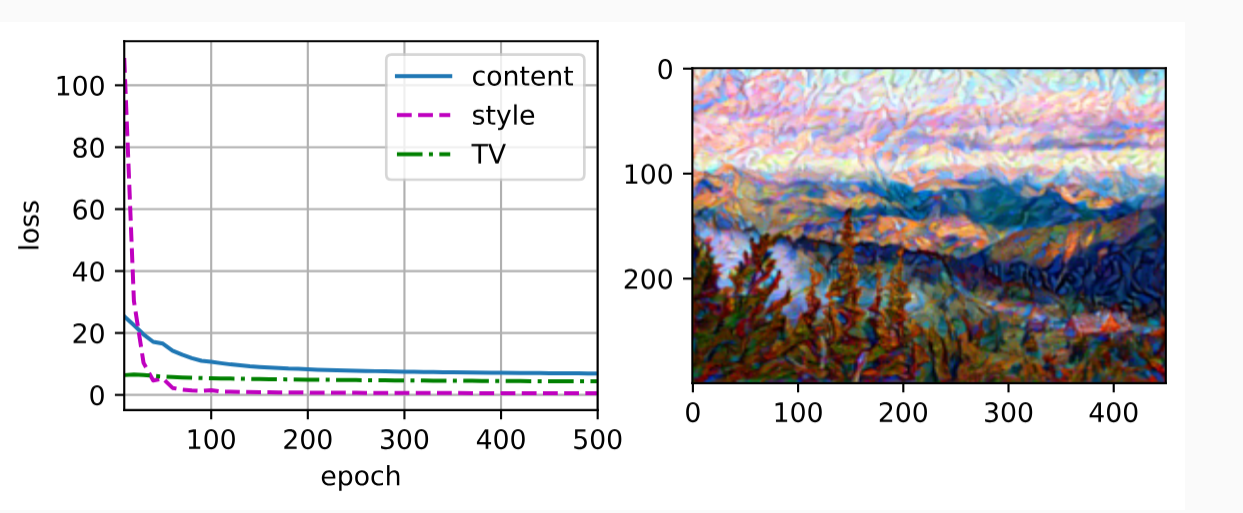

我们可以看到，合成图像保留了内容图像的风景和物体，并同时迁移了风格图像的色彩。例如，合成图像具有与风格图像中一样的色彩块，其中一些甚至具有画笔笔触的细微纹理。

## 小结

* 风格迁移常用的损失函数由3部分组成：（1）内容损失使合成图像与内容图像在内容特征上接近；（2）风格损失令合成图像与风格图像在风格特征上接近；（3）全变分损失则有助于减少合成图像中的噪点。
* 我们可以通过预训练的卷积神经网络来抽取图像的特征，并通过最小化损失函数来不断更新合成图像来作为模型参数。
* 我们使用格拉姆矩阵表达风格层输出的风格。

## 练习

1. 选择不同的内容和风格层，输出有什么变化？
1. 调整损失函数中的权重超参数。输出是否保留更多内容或减少更多噪点？
1. 替换实验中的内容图像和风格图像，能创作出更有趣的合成图像吗？
1. 我们可以对文本使用风格迁移吗？提示:可以参阅调查报告 :cite:`Hu.Lee.Aggarwal.ea.2020`。


[Discussions](https://discuss.d2l.ai/t/3300)
